## Etapa 2
Com base na última etapa, o modelo definido como base para fine-tuning foi o `convnext_tiny`

O transform tem como objetivo manipular as imagens que serão introduzidas no modelo para treino, o objetivo é testar diferentes combinações e recursos presentes no transform para descobrir o que melhor se encaixa para a solução.

In [1]:
import numpy as np

import random

import torch
import torch.nn as nn

import torchvision
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, random_split

from sklearn.metrics import f1_score, balanced_accuracy_score

# Image View
from PIL import Image

# Extra functions
from devFunctions import Imshow

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cuda


### Data
Os dados são de milho, com uma boa diferenciação entre as doenças, apresentando diferentes cores, texturas e formas.

In [2]:
from dotenv import load_dotenv
import os

In [3]:
if load_dotenv():
    print("Env carregado com sucesso.") 

    DATA_DIR = os.getenv("DATA_PATH")
    BATCH_SIZE = 32

    print(DATA_DIR)
else:
    raise ImportError("Erro ao carregar env")

Env carregado com sucesso.
/media/kaua-matheus/HD3201/Data/Agroscope/Especialista/Corn


### Transform
O transform padrão para o modelo ConvNext_Tiny

Para avaliação, não se deve aplicar filtragens ou manipulações nas imagens pois essas refletem as condições reais de uma imagem de entrada (vinda diretamente do produtor).
Diferente do treino, onde introduzimos o máximo de condições e variações com o objetivo de treinar o modelo com o máximo de possibilidades.

In [4]:
train_tf = transforms.Compose([
    
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(.85, 1.0), antialias=True),

    # transforms.RandomHorizontalFlip(0.5),

    # transforms.TrivialAugmentWide(),

    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Esse é o que teve o melhor resultado..

    transforms.ToTensor(),
    transforms.Normalize([.485, .456, .406], [.229, .224, .225])
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [.485, .456, .406], 
        [.229, .224, .225]),
])

In [5]:
full_ds = ImageFolder(DATA_DIR, transform=train_tf)
num_classes = len(full_ds.classes)

### Image View
Precisamos analisar visualmente as imagens para entender o que está acontecendo em cada ponto de alteração do transform.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27150327..1.5237038].


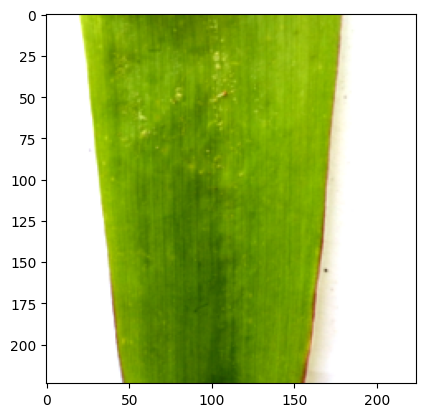

In [6]:
image = Image.open(full_ds.imgs[np.random.randint(0, len(full_ds) - 1)][0])
image_tensor = train_tf(image)

Imshow(torchvision.utils.make_grid(image_tensor.unsqueeze(0)))

In [7]:
# Pode ser simplificado
class Balance:
    def __init__(self):
        pass

    def __call__(self, value :int=None):
        class_indices = {}
        for label in range(num_classes):
            class_indices[label] = []

        for idx, (_, label) in enumerate(full_ds.imgs):
            class_indices[label].append(idx)


        low = value
        for _, imgs in class_indices.items():
            if low == None:
                low = len(imgs)
            else:
                if low >= len(imgs):
                    low = len(imgs)
                else:
                    continue

        return class_indices, low
    
    
class_indices, low = Balance().__call__(100)

In [8]:
balanced_indices = []

for class_label, indices in class_indices.items():
    if len(indices) > low:
        random.shuffle(indices)
        selected_indices = indices[:low]
    else:
        selected_indices = indices

    balanced_indices.extend(selected_indices)
    print(f"Class {class_label}: {len(selected_indices)}")

random.shuffle(balanced_indices)
dataset = Subset(full_ds, balanced_indices)

Class 0: 100
Class 1: 100
Class 2: 100


In [9]:
n = len(dataset)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

In [10]:
train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

In [11]:
val_ds.dataset.transform = eval_tf
test_ds.dataset.transform = eval_tf

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [12]:
print("Classes:", full_ds.classes)
print(f"Split -> train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

Classes: ['Healthy', 'Rust_Blight', 'Rust_Common']
Split -> train=210 val=45 test=45


### Modelo

In [13]:
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
in_f = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_f, num_classes)

# Não será utilizado no momento
# head_params = model.classifier.parameters()
# last_block_params = model.features[-1].parameters()

In [14]:
for p in model.parameters():
        p.requires_grad = False

keywords = ["fc", "classifier", "heads", "layer4", "denseblock4", "features.7", "features.8", "encoder.layers.11"]

for n, p in model.named_parameters():
    if any(k in n for k in keywords):
        p.requires_grad = True

### Otimizadores
Por que dos otimizadores?

In [15]:
epochs = 8
lr = 1e-3
weight_decay=1e-4

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

### Treino

In [17]:
model.to(DEVICE)

for epoch in range(epochs):

    running_loss = .0
    model.train()

    print(f"Iteration: {epoch + 1}")
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        inputs = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        scheduler.step()


    corrects = []
    model.eval()
    classified_right = 0

    print("Evaluation on validation set")
    for i, (images, labels) in enumerate(val_loader):
        with torch.no_grad():
            inputs = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, pred_classes = torch.max(outputs, 1)

            loss = criterion(outputs, labels)
            classified_right += (pred_classes == labels).sum().item()

    accuracy = classified_right / len(val_ds)
    print(f"Epoch {epoch + 1} Accuracy: {accuracy:.3f}")

Iteration: 1
Evaluation on validation set
Epoch 1 Accuracy: 0.956
Iteration: 2
Evaluation on validation set
Epoch 2 Accuracy: 0.933
Iteration: 3
Evaluation on validation set
Epoch 3 Accuracy: 1.000
Iteration: 4
Evaluation on validation set
Epoch 4 Accuracy: 0.978
Iteration: 5
Evaluation on validation set
Epoch 5 Accuracy: 0.956
Iteration: 6
Evaluation on validation set
Epoch 6 Accuracy: 0.956
Iteration: 7
Evaluation on validation set
Epoch 7 Accuracy: 0.844
Iteration: 8
Evaluation on validation set
Epoch 8 Accuracy: 0.933


### Teste

In [18]:
model.to(DEVICE)
model.eval()
total_loss, y_true, y_pred = 0.0, [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

avg_loss = total_loss / len(test_loader.dataset)
acc = (np.array(y_true) == np.array(y_pred)).mean()
f1m = f1_score(y_true, y_pred, average="macro")
bacc = balanced_accuracy_score(y_true, y_pred)
    
print(f"""avg_loss: {avg_loss}
acc: {acc}
f1m: {f1m}
bacc: {bacc}
""")

avg_loss: 0.13821052114168803
acc: 0.9333333333333333
f1m: 0.9178981937602627
bacc: 0.9166666666666666



# Salvando Modelo

In [ ]:
# Arrumar mecanismo de save
import datetime as dt

class Save:
    def __init__(self):
        pass

    def __call__(self, t=dt.datetime.now()):
        self.time = "{}-{}-{} {}:{}:{}".format(t.day, t.month, t.year, t.hour, t.minute, t.second)
        self.classes = full_ds.classes
        self.model_path = "./Models/Saved/Expert/Corn/corn.pth" # os.getenv("MODEL_PATH")

        if os.path.isfile(self.model_path):
            os.remove(self.model_path)

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names": self.classes,
            "num_classes": len(self.classes),
            "model_info": {
                "version": "1.0",
                "training_date": self.time,
                "accuracy": accuracy
            }
            }, self.model_path)

Save().__call__()